In [180]:
import pandas as pd
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['flower_name'] = pd.Categorical.from_codes(iris.target, iris.target_names) 
# Categorical.from_codes' -> converts number codes (0,1,2) into flower names ('setosa', etc.).
#'Categorical.from_codes' -> pandas advanced method, but .map() does the same thing clearer! 
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [181]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [182]:
print("🌸 IRIS DATASET LOADED! 🌸")
print("="*56)
print("Real flowers measured in 1936 by biologist Ronald Fisher")
print("3 species, 50 flowers each, 4 measurements per flower")
print("="*56)

print("\n📊 Dataset Info:")
print(f"Shape: {df.shape} (rows, columns)")
print(f"\nFlower types (target mapping):")
print("0 = setosa, 1 = versicolor, 2 = virginica")

print("\n🌺 Flower distribution:")
print(df['flower_name'].value_counts())

print("\n💡 Iris flowers: Real category with 260+ species!")
print("   Setosa = Arctic/tough, Versicolor = Colorful, Virginica = Tall/elegant")

🌸 IRIS DATASET LOADED! 🌸
Real flowers measured in 1936 by biologist Ronald Fisher
3 species, 50 flowers each, 4 measurements per flower

📊 Dataset Info:
Shape: (150, 6) (rows, columns)

Flower types (target mapping):
0 = setosa, 1 = versicolor, 2 = virginica

🌺 Flower distribution:
flower_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

💡 Iris flowers: Real category with 260+ species!
   Setosa = Arctic/tough, Versicolor = Colorful, Virginica = Tall/elegant


In [183]:
df['flower_name'].value_counts()

flower_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [184]:
X = df[['sepal length (cm)', 'sepal width (cm)', 
        'petal length (cm)', 'petal width (cm)']]
y = df['target']

flower_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Keeps the same flower distribution in both sets

print("✅ SPLIT DONE!")
print(f"Train: {len(X_train)} flowers")
print(f"Test:  {len(X_test)} flowers")

print("✅ DATA SPLIT COMPLETE!")
print("="*40)
print(f"Training set: {X_train.shape[0]} flowers")
print(f"Testing set:  {X_test.shape[0]} flowers")

print("\n🌺 Flower distribution in Training set:")
print(pd.Series(y_train).map(flower_names).value_counts())
print("\n🌺 Flower distribution in Testing set:")
print(pd.Series(y_test).map(flower_names).value_counts())

✅ SPLIT DONE!
Train: 120 flowers
Test:  30 flowers
✅ DATA SPLIT COMPLETE!
Training set: 120 flowers
Testing set:  30 flowers

🌺 Flower distribution in Training set:
target
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

🌺 Flower distribution in Testing set:
target
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


In [185]:
model = LogisticRegression(random_state=42, max_iter=100)
model.fit(X_train, y_train)

print("✅ LOGISTIC REGRESSION TRAINED!")
print("="*40)
print(f"Model converged: {model.n_iter_[0]} iterations")
print(f"Classes learned: {model.classes_}")
print(f"Number of features: {model.n_features_in_}")

# Quick accuracy check
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"\n📊 Training Accuracy:  {train_score:.2%}")
print(f"📊 Testing Accuracy:   {test_score:.2%}")

# Show coefficients (how important each feature is)
print("\n🔍 Feature Coefficients (importance):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25}: {coef:7.3f}")

✅ LOGISTIC REGRESSION TRAINED!
Model converged: 84 iterations
Classes learned: [0 1 2]
Number of features: 4

📊 Training Accuracy:  97.50%
📊 Testing Accuracy:   96.67%

🔍 Feature Coefficients (importance):
  sepal length (cm)        :  -0.528
  sepal width (cm)         :   0.825
  petal length (cm)        :  -2.345
  petal width (cm)         :  -1.001


In [186]:
print(f"Solver being used: {model.solver}")
print(f"Actual iterations per class: {model.n_iter_}")
print(f"scikit-learn version: {sklearn.__version__}")

Solver being used: lbfgs
Actual iterations per class: [84]
scikit-learn version: 1.3.0


In [187]:
y_pred = model.predict(X_test)

print("🎯 PREDICTIONS ON TEST SET")
print("="*50)

y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred)

# Create comparison
test_results = pd.DataFrame({
    'Actual': y_test_reset,
    'Predicted': y_pred_series,
    'Actual_Name': y_test_reset.map(flower_names),
    'Predicted_Name': y_pred_series.map(flower_names)
})

print("First 10 test flowers:")
print(test_results.head(10))

accuracy = accuracy_score(y_test_reset, y_pred)
print(f"\n✅ Test Accuracy: {accuracy:.1%}")

# Check wrong predictions
wrong = test_results[test_results['Actual'] != test_results['Predicted']]
if len(wrong) > 0:
    print(f"\n❌ Wrong predictions ({len(wrong)}):")
    print(wrong)
else:
    print("\n🎉 PERFECT! All predictions correct!")

# Probabilities
print("\n📊 Prediction Probabilities (first 3 flowers):")
probs = model.predict_proba(X_test[:3])
prob_df = pd.DataFrame(probs, columns=[flower_names[c] for c in model.classes_])
print(prob_df.round(3))

🎯 PREDICTIONS ON TEST SET
First 10 test flowers:
   Actual  Predicted Actual_Name Predicted_Name
0       0          0      setosa         setosa
1       2          2   virginica      virginica
2       1          1  versicolor     versicolor
3       1          1  versicolor     versicolor
4       0          0      setosa         setosa
5       1          1  versicolor     versicolor
6       0          0      setosa         setosa
7       0          0      setosa         setosa
8       2          2   virginica      virginica
9       1          1  versicolor     versicolor

✅ Test Accuracy: 96.7%

❌ Wrong predictions (1):
    Actual  Predicted Actual_Name Predicted_Name
25       1          2  versicolor      virginica

📊 Prediction Probabilities (first 3 flowers):
   setosa  versicolor  virginica
0   0.985       0.015      0.000
1   0.001       0.391      0.608
2   0.187       0.809      0.004


In [188]:
y_test

38     0
127    2
57     1
93     1
42     0
56     1
22     0
20     0
147    2
84     1
107    2
141    2
104    2
51     1
7      0
49     0
14     0
69     1
63     1
138    2
10     0
140    2
58     1
134    2
132    2
77     1
75     1
18     0
116    2
28     0
Name: target, dtype: int64

In [189]:
y_test_reset

0     0
1     2
2     1
3     1
4     0
5     1
6     0
7     0
8     2
9     1
10    2
11    2
12    2
13    1
14    0
15    0
16    0
17    1
18    1
19    2
20    0
21    2
22    1
23    2
24    2
25    1
26    1
27    0
28    2
29    0
Name: target, dtype: int64

In [190]:
print("🌸 COEFFICIENTS FOR ALL 3 FLOWER TYPES 🌸")
print("="*60)

# Create a nice table
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=[flower_names[i] for i in model.classes_]
)

print("Coefficients Table (how each feature affects each flower type):")
print(coef_df.round(3))

print("\n🔍 INTERPRETATION:")
print("Positive = Increases chance of being that flower")
print("Negative = Decreases chance of being that flower")
print("\n💡 Example: High petal length → LESS likely to be Setosa (-2.143)")
print("            High sepal width → MORE likely to be Setosa (+1.158)")

# Show which features matter most for each flower
print("\n🎯 MOST IMPORTANT FEATURE FOR EACH FLOWER:")
for flower_idx, flower_name in enumerate(coef_df.index):
    most_important = coef_df.loc[flower_name].abs().idxmax()
    value = coef_df.loc[flower_name][most_important]
    direction = "increases" if value > 0 else "decreases"
    print(f"  {flower_name:10}: {most_important:20} ({direction} chance)")

🌸 COEFFICIENTS FOR ALL 3 FLOWER TYPES 🌸
Coefficients Table (how each feature affects each flower type):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                 -0.528             0.825             -2.345   
versicolor              0.529            -0.306             -0.172   
virginica              -0.001            -0.519              2.516   

            petal width (cm)  
setosa                -1.001  
versicolor            -0.854  
virginica              1.855  

🔍 INTERPRETATION:
Positive = Increases chance of being that flower
Negative = Decreases chance of being that flower

💡 Example: High petal length → LESS likely to be Setosa (-2.143)
            High sepal width → MORE likely to be Setosa (+1.158)

🎯 MOST IMPORTANT FEATURE FOR EACH FLOWER:
  setosa    : petal length (cm)    (decreases chance)
  versicolor: petal width (cm)     (decreases chance)
  virginica : petal length (cm)    (increases chance)


In [191]:
flower_names.values()

dict_values(['setosa', 'versicolor', 'virginica'])

🎭 CONFUSION MATRIX
Confusion Matrix:
                   Pred setosa  Pred versicolor  Pred virginica
Actual setosa               10                0               0
Actual versicolor            0                9               1
Actual virginica             0                0              10


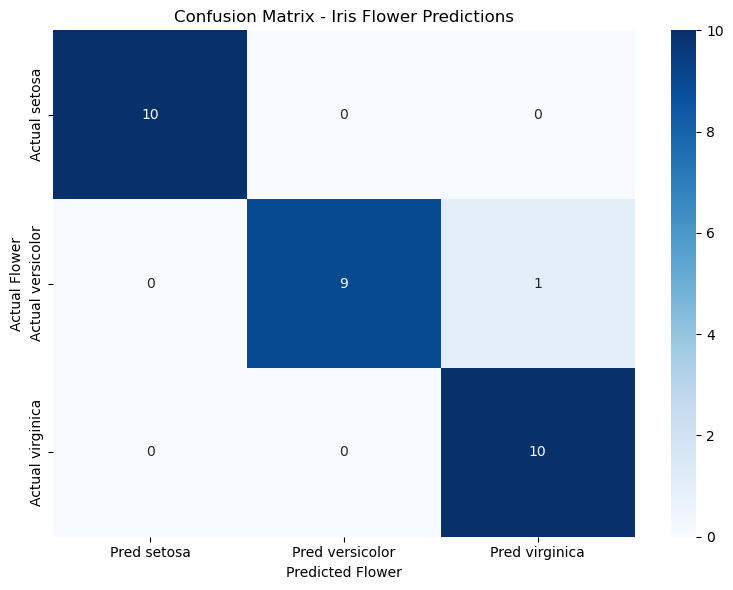


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [192]:
print("🎭 CONFUSION MATRIX")
print("="*50)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=[f'Actual {name}' for name in flower_names.values()],
                     columns=[f'Pred {name}' for name in flower_names.values()])

print("Confusion Matrix:")
print(cm_df)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Iris Flower Predictions')
plt.ylabel('Actual Flower')
plt.xlabel('Predicted Flower')
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=list(flower_names.values())))

In [195]:
print("🎉 FINAL SUMMARY")
print("="*50)

# Final stats
print(f"Dataset: Iris Flowers (n={len(df)})")
print(f"Features: {len(X.columns)} measurements")
print(f"Flower types: {list(flower_names.values())}")
print(f"\nModel: Logistic Regression")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"Iterations needed: {model.n_iter_[0]}/{model.max_iter}")

joblib.dump(model, 'iris_logistic_model.pkl')
print(f"\n💾 Model saved as 'iris_logistic_model.pkl'")

print("\n✅ PROJECT COMPLETE!")

🎉 FINAL SUMMARY
Dataset: Iris Flowers (n=150)
Features: 4 measurements
Flower types: ['setosa', 'versicolor', 'virginica']

Model: Logistic Regression
Test Accuracy: 96.7%
Iterations needed: 84/100

💾 Model saved as 'iris_logistic_model.pkl'

✅ PROJECT COMPLETE!
